## Sampling depth

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import netCDF4 as nc
from sklearn.preprocessing import MinMaxScaler
import cartopy.crs as ccrs  
import cartopy.feature as cfeature
import numpy as np
from scipy.spatial import cKDTree
from scipy import stats

In [3]:
folder = pd.read_csv("..\\0.2 Coastal shelf sediments grid\\Continental shelf grid.csv")
folder

,Lat_center,Lon_center,El_mean,MP_std,n_points
0,-81.5,160.5,-44.000000,16.522712,3
1,-81.5,161.5,-170.000000,4.242641,2
2,-79.5,160.5,-9.500000,2.121320,2
3,-79.5,175.5,-178.000000,NaN,1
4,-79.5,176.5,-88.000000,121.622366,2
...,...,...,...,...,...
10163,84.5,-35.5,-187.051282,6.480532,39
10164,84.5,-34.5,-189.600000,5.639149,5
10165,84.5,-32.5,-171.947368,14.001880,19
10166,84.5,-31.5,-156.083333,12.109037,12


In [5]:
data = pd.read_csv('..\\0.1 MP abundance data collection\FINAL gridded concentrations.csv')
data

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1
...,...,...,...,...,...,...
99,Fragments,73.5,-169.5,2.962179e-01,NaN,1
100,Fragments,73.5,-168.5,3.155131e-01,NaN,1
101,Fragments,74.5,-173.5,1.647974e-01,NaN,1
102,Fragments,75.5,-179.5,8.402756e-01,NaN,1


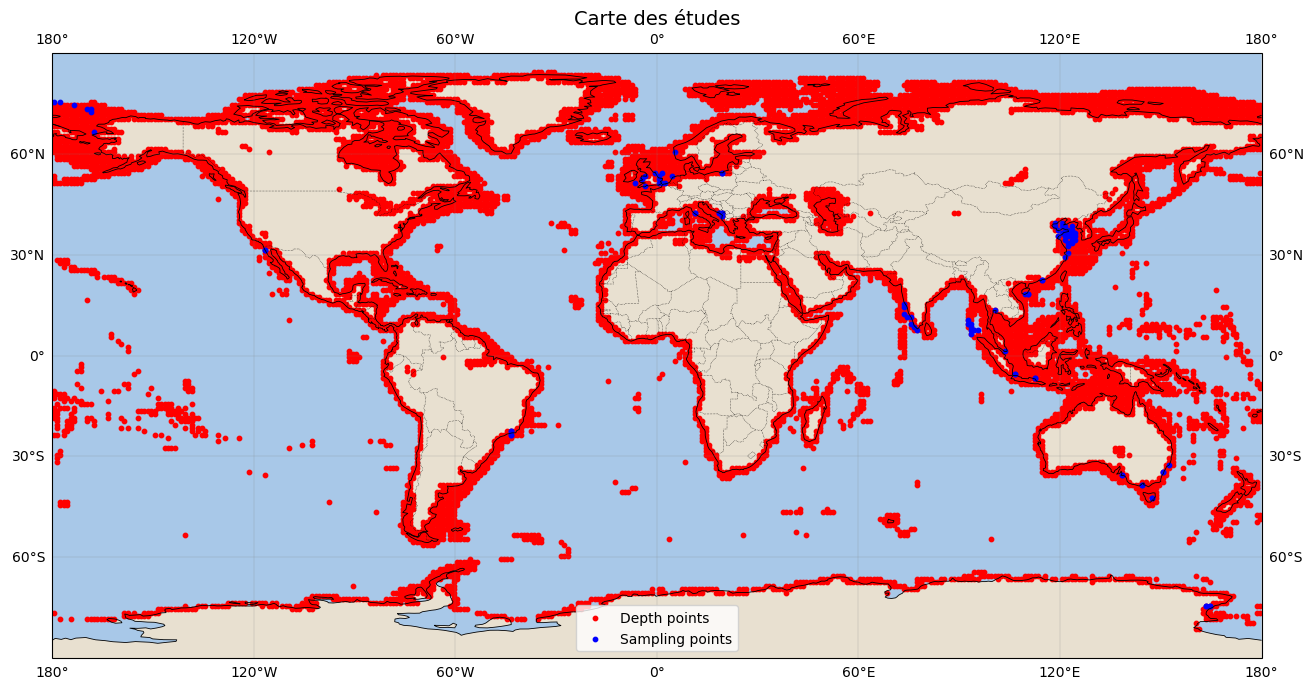

In [6]:

latitudes_folder  = np.array(folder["Lat_center"], dtype=float)
longitudes_folder = np.array(folder["Lon_center"], dtype=float)

depth = np.array(folder["El_mean"], dtype=float)

discharge_folder = list(zip(latitudes_folder, longitudes_folder, depth))

lats_folder   = [p[0] for p in discharge_folder]
lons_folder   = [p[1] for p in discharge_folder]
# Format: (latitude, longitude, "Label")

# ──────────────────────────────────────────────────────────────────────────────
latitudes_data  = np.array(data["Lat_center"], dtype=float)
longitudes_data = np.array(data["Lon_center"], dtype=float)

points_data = list(zip(latitudes_data, longitudes_data))
# Format: (latitude, longitude, "Label")

lats_data   = [p[0] for p in points_data]
lons_data   = [p[1] for p in points_data]


### Plot

fig = plt.figure(figsize=(14, 7))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

ax.set_global()
ax.add_feature(cfeature.LAND,       facecolor="#e8e0d0")
ax.add_feature(cfeature.OCEAN,      facecolor="#a8c8e8")
ax.add_feature(cfeature.COASTLINE,  linewidth=0.6)
ax.add_feature(cfeature.BORDERS,    linewidth=0.4, linestyle=":")
ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)

ax.scatter(lons_folder, lats_folder, s=10, color="red", zorder=1, transform=ccrs.PlateCarree(), label = 'Depth points')
ax.scatter(lons_data, lats_data, s=10, color="blue", zorder=1, transform=ccrs.PlateCarree(), label = 'Sampling points')

plt.title("Carte des études", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:

def compute_distances(lat, lon, lats, lons):
    """Computes distances in km using the Haversine formula"""
    R = 6378
    lat1, lon1, lat2, lon2 = np.radians(lat), np.radians(lon), np.radians(lats), np.radians(lons)
    dLat = (lat2-lat1)
    dLon = (lon2-lon1)
    d = 2*R*np.arcsin(np.sqrt((np.sin(dLat/2))**2 + np.cos(lat1) * np.cos(lat2) * (np.sin(dLon/2))**2))
    return d

points_arr = np.array(discharge_folder, dtype=object)
coords     = np.array([(p[0], p[1]) for p in discharge_folder], dtype=float)

In [8]:
distances = compute_distances(lats_data[0], lons_data[0], lats_folder,lons_folder)
distances = distances[np.isfinite(distances)]
np.min(distances)

np.float64(0.0)

In [9]:
def nearest_depth( lat, lon, coords, points_array):
    """ Returns distance from sapling point to nearest river discharge point and its associated values. 4 ways to search for nearest point exist:
    nearest point - finds the smallest distance
    sum of 5 nearests - finds 5 smallest distances and does the sum of values for each columns, mean distance is considered
    100 km radius - finds the smallest distance and then sums all municipalities in a 100 km radius around the nearest one
    50 km radius - finds the smallest distance and then sums all municipalities in a 50 km radius around the nearest one
    Mean value over multiple river discharges were found to be not good indicators.
    """

    distances = compute_distances(lat, lon, coords[:, 0], coords[:, 1])
    distances = distances[np.isfinite(distances)]

    
    idx_nearest = np.argmin(distances)
    nearest = points_array[idx_nearest]
    nearest = np.array(nearest, dtype=object)
    return nearest[2]
    

In [10]:
result = []

for lat, lon in zip(lats_data, lons_data):
    output = nearest_depth(lat = lat, lon = lon, coords = coords, points_array = points_arr)
    result.append(output)

In [11]:
len(result)

104

In [12]:

output = pd.DataFrame(result, columns=['Depth'])
output

,Depth
0,-79.666667
1,-89.444444
2,-14.860000
3,-61.179545
4,-37.409836
...,...
99,-116.460069
100,-116.869792
101,-195.086957
102,-193.214286


In [13]:
data_points_expended = pd.concat([data, output], axis = 1)
data_points_expended.to_csv('outputs\Sampling depth.csv',index=False)
data_points_expended

,Shape,Lat_center,Lon_center,MEAN MP stock (g/m2) in 2021,MP_std,n_points,Depth
0,Fibers,-74.5,163.5,3.353587e-08,NaN,1,-79.666667
1,Fibers,-74.5,164.5,4.351279e-07,1.732525e-07,10,-89.444444
2,Fibers,-42.5,147.5,1.041953e-02,NaN,1,-14.860000
3,Fibers,-38.5,144.5,1.395096e-02,NaN,1,-61.179545
4,Fibers,-35.5,138.5,9.684738e-03,NaN,1,-37.409836
...,...,...,...,...,...,...,...
99,Fragments,73.5,-169.5,2.962179e-01,NaN,1,-116.460069
100,Fragments,73.5,-168.5,3.155131e-01,NaN,1,-116.869792
101,Fragments,74.5,-173.5,1.647974e-01,NaN,1,-195.086957
102,Fragments,75.5,-179.5,8.402756e-01,NaN,1,-193.214286


In [14]:

parameters = ['Depth']

In [15]:
# Normalize data for statistics
data_points_copy = data_points_expended.copy()
cols_to_normalize = [
                     'MEAN MP stock (g/m2) in 2021',
                     *parameters]

scaler = MinMaxScaler()
data_points_copy[cols_to_normalize] = scaler.fit_transform(data_points_copy[cols_to_normalize])

# Divide fibers from fragments
data_points_fib = data_points_copy[data_points_copy["Shape"] == "Fibers"]
data_points_frg = data_points_copy[data_points_copy["Shape"] == "Fragments"]

In [16]:
spearman_results = []

# Fibers


for key in parameters:
    x = data_points_fib[key]
    y = data_points_fib["MEAN MP stock (g/m2) in 2021"]

    # Remove NaNs
    mask = np.isfinite(x) & np.isfinite(y) 

    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'{key} fibers stock', spearman_stock[0], spearman_stock[1]))


for key in parameters:
    x = data_points_frg[key]
    y = data_points_frg["MEAN MP stock (g/m2) in 2021"]

    # Remove NaNs
    mask = np.isfinite(x) & np.isfinite(y) 

    spearman_stock = stats.spearmanr(x[mask], y[mask])
    spearman_results.append((f'{key} frgers stock', spearman_stock[0], spearman_stock[1]))
    

In [17]:
results_stats = pd.DataFrame(spearman_results, columns=["Parameter", "Spearman Correlation", "Spearman p-value"])
results_stats.sort_values(by = "Spearman Correlation")

,Parameter,Spearman Correlation,Spearman p-value
1,Depth frgers stock,0.312348,0.052881
0,Depth fibers stock,0.323980,0.008470
